# CGLMP Inequalities

Juan Manuel Segura Guatibonza

In [1]:
include("SDP_QI.jl")


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


CGLMP_analysis_2D (generic function with 2 methods)

\begin{align*}
    \hat{X}_d &= \sum_{j=0}^{d-1} | j \rangle \langle j \oplus 1| \\
    \hat{F}_d &= \frac{1}{\sqrt{d}} \sum_{j,k} \omega_d^{jk} |j \rangle \langle k | \\
    \omega_d &= e^{2\pi i /d}
\end{align*}

The CGLMP ineuality is the following:

\begin{align*}
    I_d = \sum_{k=0}^{d/2 - 1} \left( 1 - \frac{2k}{d-1} \right) &\left[ (P(A_1 = B_1 + k) + P(B_1=A_2 + k +1) + P(A_2 = B_2+k) + (B_2 = A_1+k)) \right. \\
    & \left. - (P(A_1=B_1-k-1) + P(B_1=A_2-k) + P(A_2=B_2-k-1) + P(B_2=A_1-k-1)) \right]
\end{align*}

where

\begin{equation*}
    P(A_a = B_b + k) = \sum_{j=0}^{d-1} P(A_a=j, B_b= j+k \operatorname{mod} d)
\end{equation*}

Los elementos de medición de $A_1$ y $B_1$ son:
\begin{equation*}
    \Pi_{j|1} = |j\rangle \langle j | \quad , \quad j=0,\dots,d-1
\end{equation*}

Los elementos de medición de $A_2$ y $B_2$ son:
\begin{equation*}
    \Pi_{j|2} = \hat{M}_d|j\rangle \langle j | \hat{M}_d^\dagger \quad , \quad j=0,\dots,d-1
\end{equation*}

donde

\begin{equation*}
    \hat{M}_d = \hat{F}_d^{(1-\alpha)} \hat{X}_d^{-\alpha/2} \quad , \quad \alpha \in \left[0, 1 \right]
\end{equation*}

In [3]:
Threads.nthreads()

4

In [ ]:
for d in 2:10
    CGLMP_analysis(d)
end

Terminated process for α = 0.0
Terminated process for α = 0.2525
Terminated process for α = 0.5051
Terminated process for α = 0.7576
Terminated process for α = 0.5152
Terminated process for α = 0.7677
Terminated process for α = 0.2626
Terminated process for α = 0.0101
Terminated process for α = 0.5253
Terminated process for α = 0.7778
Terminated process for α = 0.0202
Terminated process for α = 0.5354
Terminated process for α = 0.7879
Terminated process for α = 0.0303
Terminated process for α = 0.5455
Terminated process for α = 0.5556
Terminated process for α = 0.798
Terminated process for α = 0.0404
Terminated process for α = 0.5657
Terminated process for α = 0.8081
Terminated process for α = 0.5758
Terminated process for α = 0.0505
Terminated process for α = 0.5859
Terminated process for α = 0.8182
Terminated process for α = 0.596
Terminated process for α = 0.2727
Terminated process for α = 0.0606
Terminated process for α = 0.8283
Terminated process for α = 0.6061
Terminated process 

In [96]:
function Plot_CGLMP(d::Int)
    set_theme!(Theme(
        fontsize = 18,
        fonts = (; regular = "CMU Serif"),
        Axis = (
            xgridvisible = true,
            ygridvisible = true,
            topspinevisible = true,
            rightspinevisible = true,
            spinewidth = 1.2,
        )
    ))

    f = Figure(size = (2000, 1500))

    Label(f[0, 1:2],
        "Optimal violation of the CGLMP inequality (d=$(d))",
        fontsize = 30,
        halign = :center
    )

    ax1 = Axis(f[1, 1],
        ylabel = "CGLMP",
        titlesize = 25,
        xticks = 0:0.2:1,
        ylabelsize = 22
    )

    ax2 = Axis(f[2, 1],
        ylabel = "Entanglement robustness",
        xticks = 0:0.2:1,
        ylabelsize = 22
    )

    ax3 = Axis(f[3, 1],
        xlabel = L"\alpha",
        ylabel = "Measurement incompatibility",
        xticks = 0:0.2:1,
        xlabelsize = 23,
        ylabelsize = 22
    )

    ax4 = Axis(f[1, 2],
        ylabel = "Entanglement entropy",
        xticks = 0:0.2:1,
        ylabelsize = 22
    )

    ax5 = Axis(f[2, 2],
        ylabel = "Negativity",
        xticks = 0:0.2:1,
        ylabelsize = 22
    )

    ax6 = Axis(f[3, 2],
        xlabel = L"\alpha",
        ylabel = "Non-commutativity",
        xticks = 0:0.2:1,
        xlabelsize = 23,
        ylabelsize = 22
    )

    linkxaxes!(ax1, ax2, ax3)
    linkxaxes!(ax4, ax5, ax6)

    df = CSV.read("resultsCGLMP/cglmp_d$(d).csv", DataFrame)
    alphas = df.alpha
    cglmp = df.CGLMP
    entanglement = df.Entanglement
    incompatibility = 1 .- df.NoiseDual
    neg_primal = df.Neg_primal
    neg_dual = df.Neg_dual
    non_commutativity = df.Incomp_NC
    vn_entropy = df.vn_entropy
    ent_entropy = df.ent_entropy

    lines!(ax1, alphas, cglmp, linewidth = 2)
    scatter!(ax1, alphas, cglmp, markersize = 5)

    lines!(ax2, alphas, entanglement, linewidth = 2)
    scatter!(ax2, alphas, entanglement, markersize = 5)

    lines!(ax3, alphas, incompatibility, linewidth = 2)
    scatter!(ax3, alphas, incompatibility, markersize = 5)

    lines!(ax4, alphas, ent_entropy, linewidth = 2)
    scatter!(ax4, alphas, ent_entropy, markersize = 5)

    lines!(ax5, alphas, neg_primal, linewidth = 2)
    scatter!(ax5, alphas, neg_primal, markersize = 5)

    lines!(ax6, alphas, non_commutativity, linewidth = 2)
    scatter!(ax6, alphas, non_commutativity, markersize = 5)

    hidexdecorations!(ax1, ticks=false, grid=false)
    hidexdecorations!(ax2, ticks=false, grid=false)
    hidexdecorations!(ax4, ticks=false, grid=false)
    hidexdecorations!(ax5, ticks=false, grid=false)

    xlims!(ax3, 0, 1)
    xlims!(ax6, 0, 1)

    rowgap!(f.layout, 10)

    save("resultsCGLMP/cglmp_d$(d).pdf", f, pt_per_unit=3)

    Mean = mean(vn_entropy)
    Std  = std(vn_entropy)

    println("The von Neumann entropy for d=$(d) is: $(round(Mean, digits=7)) +/- $(round(Std, digits=7))")

    #= g = Figure(size = (1000, 1000))

    Label(g[0, 1],
        "Optimal violation of the CGLMP inequality (d=$(d))",
        fontsize = 30,
        halign = :center
    )

    ax = Axis3(g[1, 1], 
        xlabel = "Entanglement entropy", 
        ylabel = "Measurement Incompatibility", 
        zlabel = "Max CGLMP",
        xlabelsize = 22,
        ylabelsize = 22,
        zlabelsize = 22
    )
    scatter!(ax, ent_entropy, non_commutativity, cglmp, markersize = 5)
    lines!(ax, ent_entropy, non_commutativity, cglmp, linewidth = 2)

    save("resultsCGLMP/cglmp_correlations_d$(d).pdf", g, pt_per_unit=3) =#

    cor_pearson = cor([ent_entropy non_commutativity cglmp])

    var_names = ["Ent. entropy", "Non-comm.", "CGLMP"]

    g = Figure(size = (1000, 1000))
        ax = Axis(g[1, 1],
        title = "Pearson coefficient",
        titlesize = 30,
        xticks = (1:3, var_names),
        yticks = (1:3, var_names),
        xticklabelrotation = π/4,
        yreversed = true
    )
    hm = heatmap!(ax, cor_pearson, colormap = :viridis)
    Colorbar(g[1, 2], hm)
    save("resultsCGLMP/cglmp_correlations_d$(d).pdf", g, pt_per_unit=3)

end

Plot_CGLMP (generic function with 1 method)

In [97]:
for d in 2:10
    Plot_CGLMP(d)
end

The von Neumann entropy for d=2 is: 0.000171 +/- 0.0004949
The von Neumann entropy for d=3 is: 0.001303 +/- 0.0018466
The von Neumann entropy for d=4 is: 0.001493 +/- 0.0029351
The von Neumann entropy for d=5 is: 0.001228 +/- 0.0027844
The von Neumann entropy for d=6 is: 0.0005596 +/- 0.0011564
The von Neumann entropy for d=7 is: 0.0002144 +/- 0.0005646
The von Neumann entropy for d=8 is: 0.0007604 +/- 0.0038551
The von Neumann entropy for d=9 is: 0.0005489 +/- 0.00124
The von Neumann entropy for d=10 is: 0.0006951 +/- 0.0019274


## Incompatibility vs $\theta$ (First approximation)

The first measurement will be done in the measurement basis of $\sigma_z$. On the other hand, the second measurement will be done in the measurement basis of the following Pauli axis:

\begin{equation*}
    \sin(\theta) \sigma_x + \cos(\theta) \sigma_z \quad \text{,} \quad \theta \in \left[ 0, \pi/2 \right]
\end{equation*}

In [2]:
# Given an operator, return its projectors
function Projectors(A::AbstractMatrix)
    eigvec     = eigvecs(A)
    projectors = [eigvec[:, i] * eigvec[:, i]' for i in 1:size(eigvec, 2)] 
    return projectors
end

# Given θ, return the Pauli axis tilted by θ relative to σz
function Pauli_theta(θ::Float64)
    sigma_x = [0 1 ; 1 0]
    sigma_z = [1 0 ; 0 -1]
    projectors = Projectors(sin(θ) * sigma_x + cos(θ) * sigma_z)
    return projectors
end

# Weyl operator in dimension d and subindexes m and n
function Weyl(d::Integer, m::Integer, n::Integer)
    U = zeros(ComplexF64, d, d)

    for i in 1:d
        col = mod(i-1 - n, d) + 1 
        U[i, col] = exp(2π * im * m * (i-1) / d)
    end

    return U
end

# Given θ, return the tilted measurement between Z and X for qudits
function XZ_qudit_theta(d::Int, θ::Float64)
    Xd = Weyl(d, 0, 1)
    Zd = Weyl(d, 1, 0)
    projectors = Projectors(sin(θ) * Xd + cos(θ) * Zd)
    return projectors
end

XZ_qudit_theta (generic function with 1 method)

In [3]:
# Calculate the maximal violation of CGLMP in dimesion d for a meaurement fixed in Z and the other measurement tilted from θ∈[0,π/2]
function CGLMP_theta(d::Integer)
    N = 100
    θ_deg = LinRange(0, 90, N)
    θ_rad = deg2rad.(θ_deg)

    # Projectors of Z for qudits
    P_z = Projectors(Weyl(d, 1, 0))

    incomp = fill!(similar(θ_rad), 0.0)
    cglmp  = fill!(similar(θ_rad), 0.0)
    entang = fill!(similar(θ_rad), 0.0)

    for (i, θ) in enumerate(θ_rad)
        P_θ = XZ_qudit_theta(d, θ)

        incomp[i]   = MI_NC(P_z, P_θ, 2.0) 
        cglmp[i], ρ = CGLMP_opt([P_z, P_θ], [P_z, P_θ], d)
        entang[i]   = Ent_entropy(ρ, d, d)
    end

    set_theme!(Theme(
        fontsize = 18,
        fonts = (; regular = "CMU Serif"),
        Axis = (
            xgridvisible = true,
            ygridvisible = true,
            topspinevisible = true,
            rightspinevisible = true,
            spinewidth = 1.2,
        )
    ))

    f = Figure(size = (1000, 750))

    ax = Axis(f[1, 1],
        xlabel = "θ [°]",
        ylabel = "Measurement Incompatibility",
        titlesize = 25,
        xlabelsize = 22,
        ylabelsize = 22
    )

    lines!(ax, θ_deg, incomp, linewidth = 2)
    scatter!(ax, θ_deg, incomp, markersize = 5)
    display(f)

    g = Figure(size = (1000, 750))

    ax = Axis(g[1, 1],
        xlabel = "θ [°]",
        ylabel = "CGLMP maximal violation",
        titlesize = 25,
        xlabelsize = 22,
        ylabelsize = 22
    )

    lines!(ax, θ_deg, cglmp, linewidth = 2)
    scatter!(ax, θ_deg, cglmp, markersize = 5)
    display(g)

    h = Figure(size = (1000, 750))

    ax = Axis(h[1, 1],
        xlabel = "θ [°]",
        ylabel = "Entanglement entropy",
        titlesize = 25,
        xlabelsize = 22,
        ylabelsize = 22
    )

    lines!(ax, θ_deg, entang, linewidth = 2)
    scatter!(ax, θ_deg, entang, markersize = 5)
    display(h)

end

CGLMP_theta (generic function with 1 method)

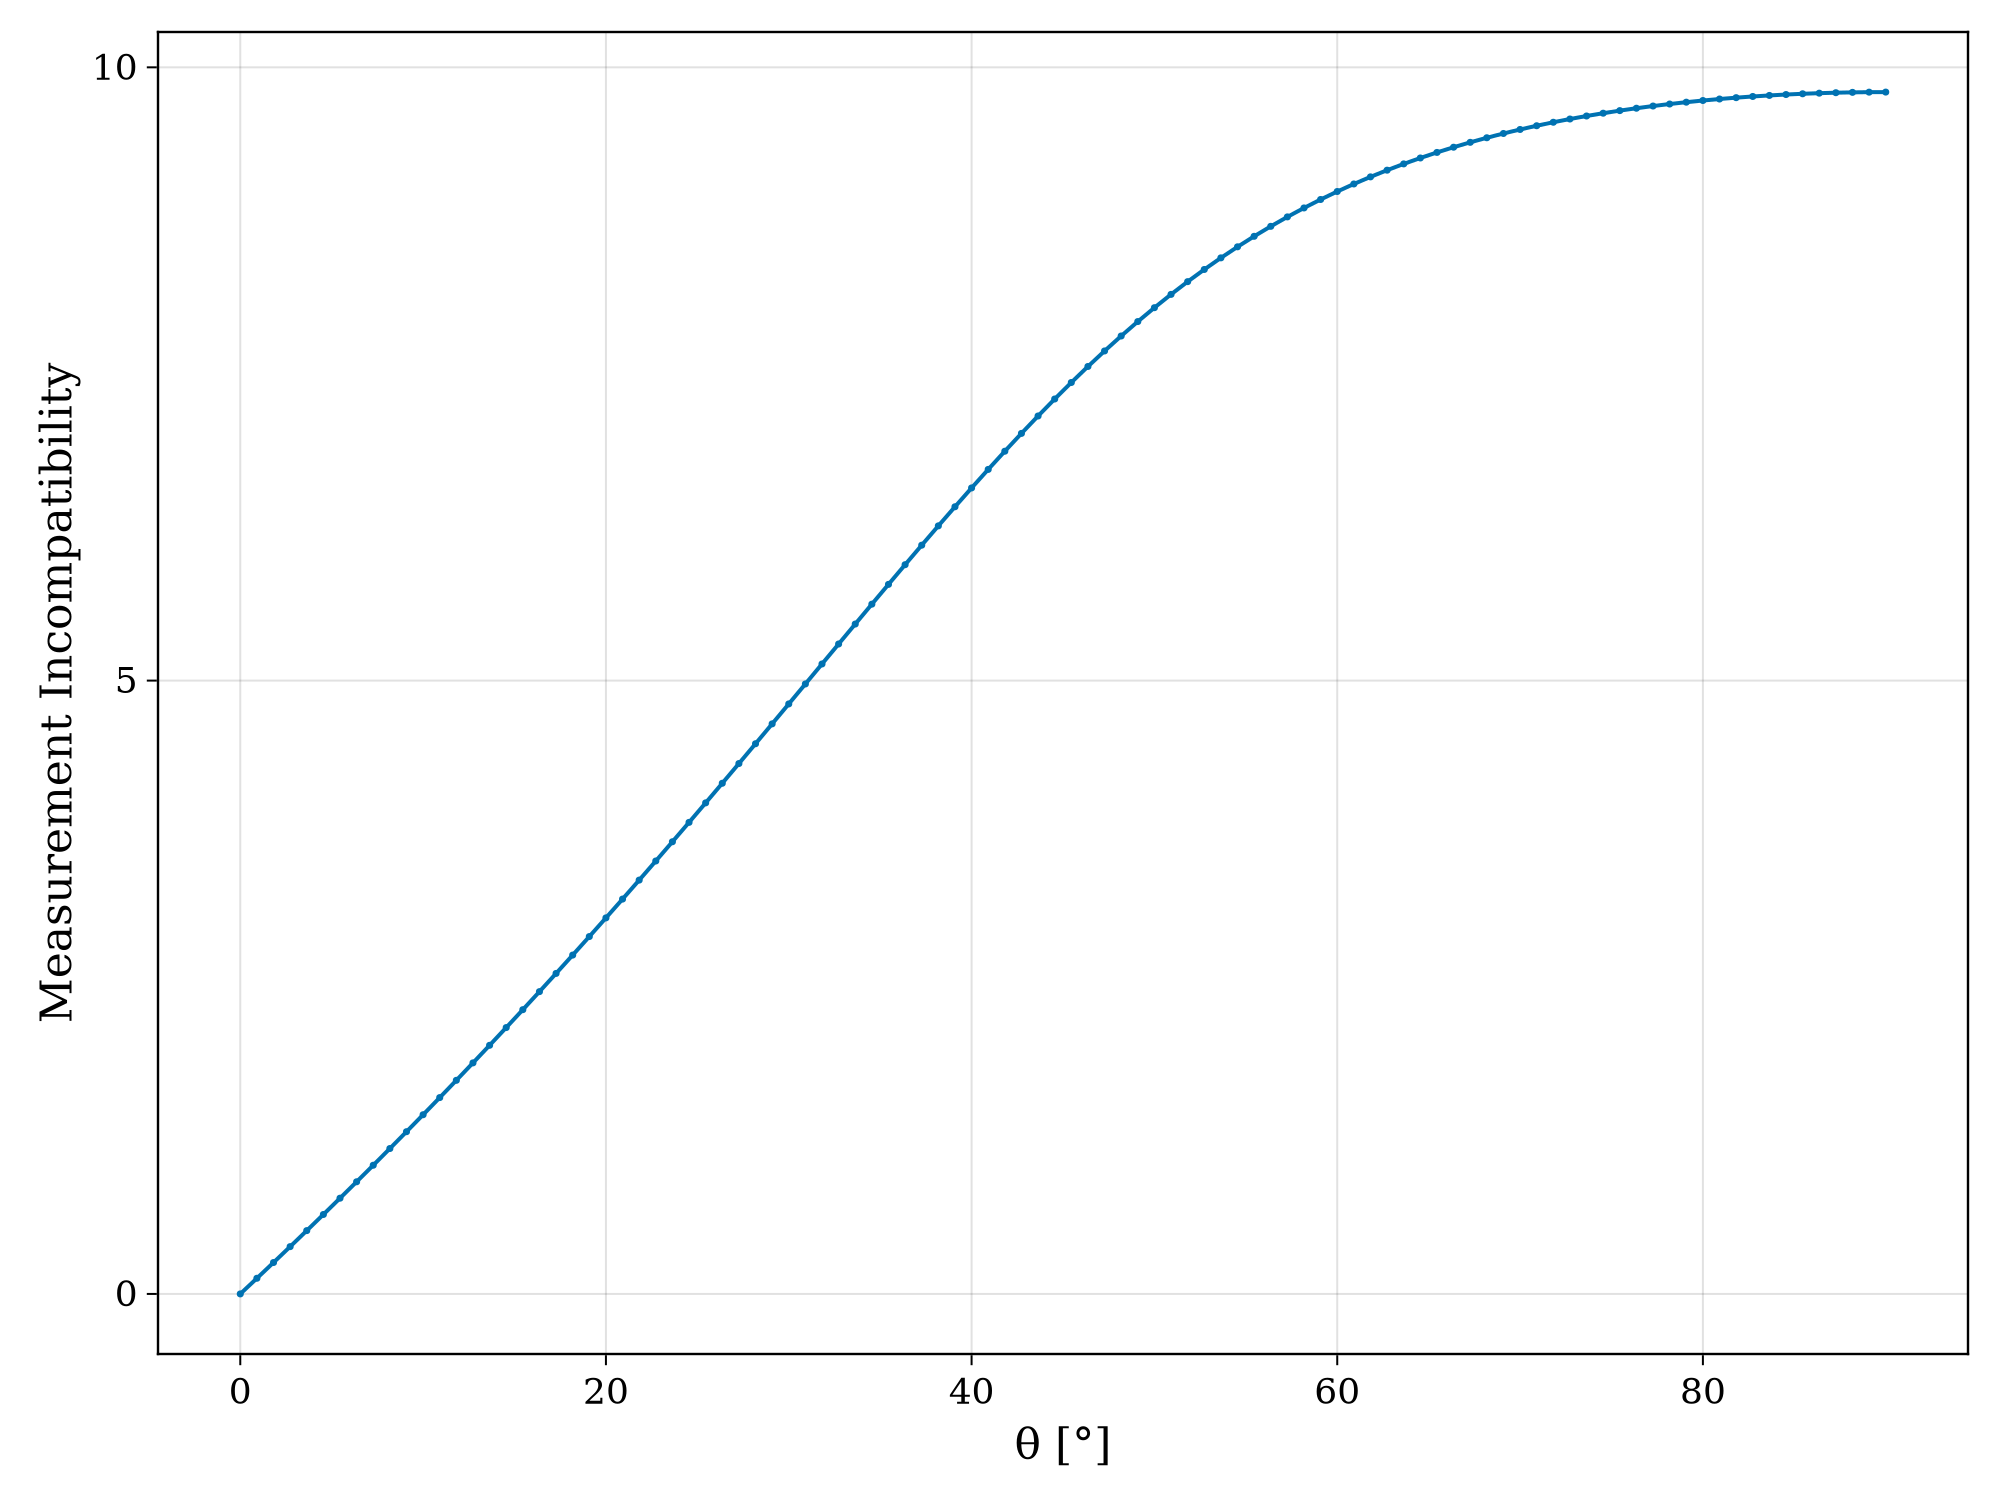

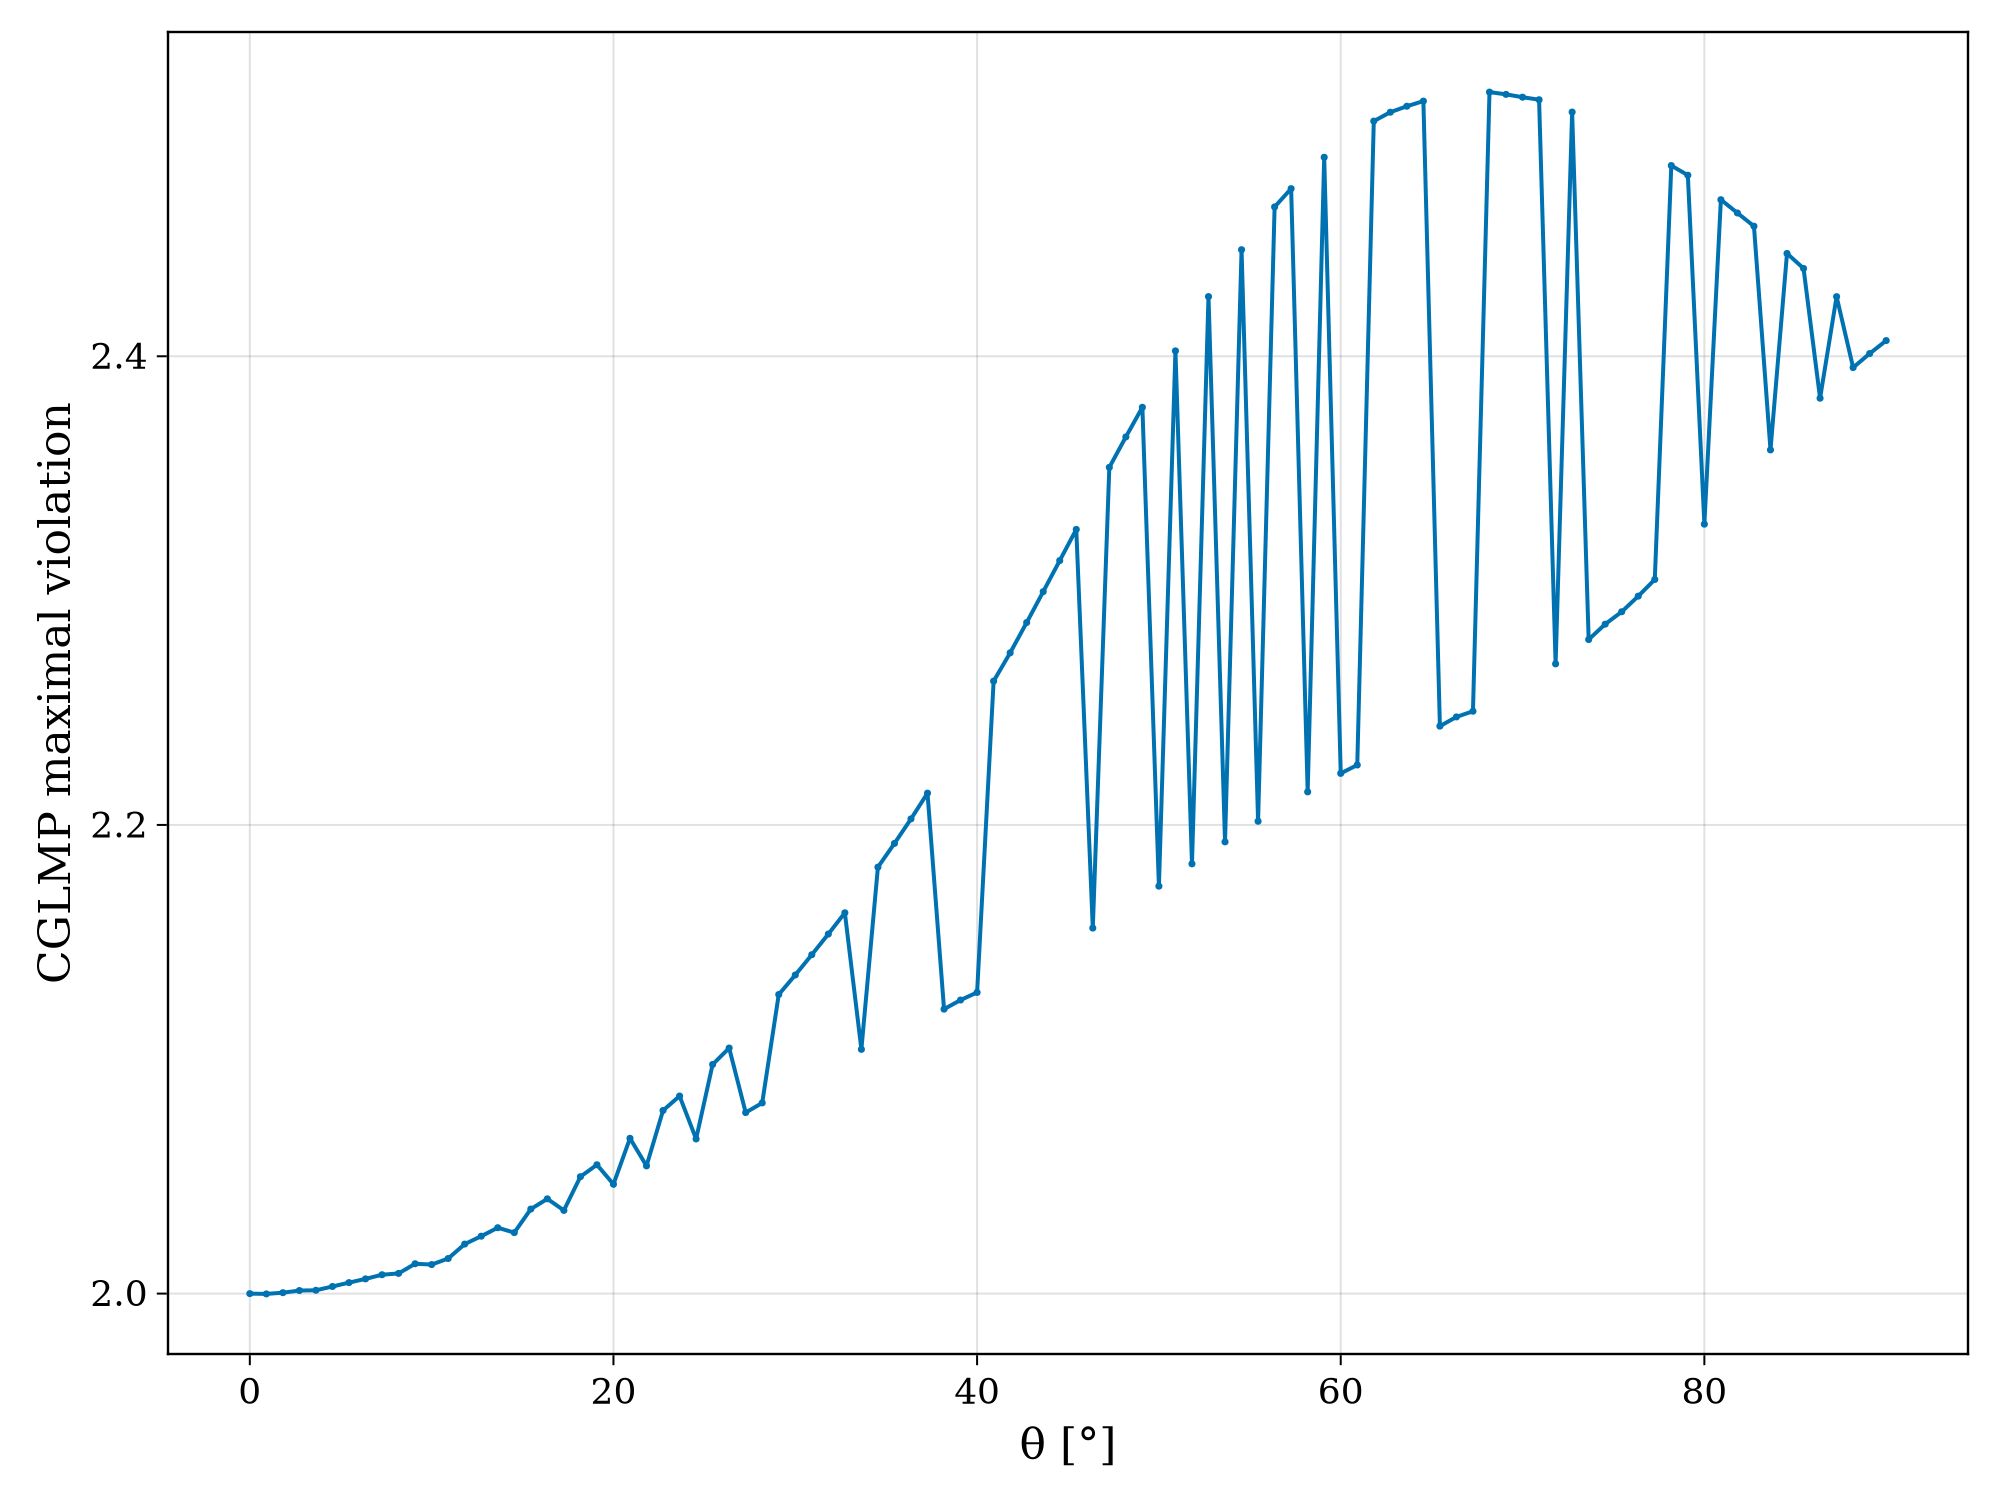

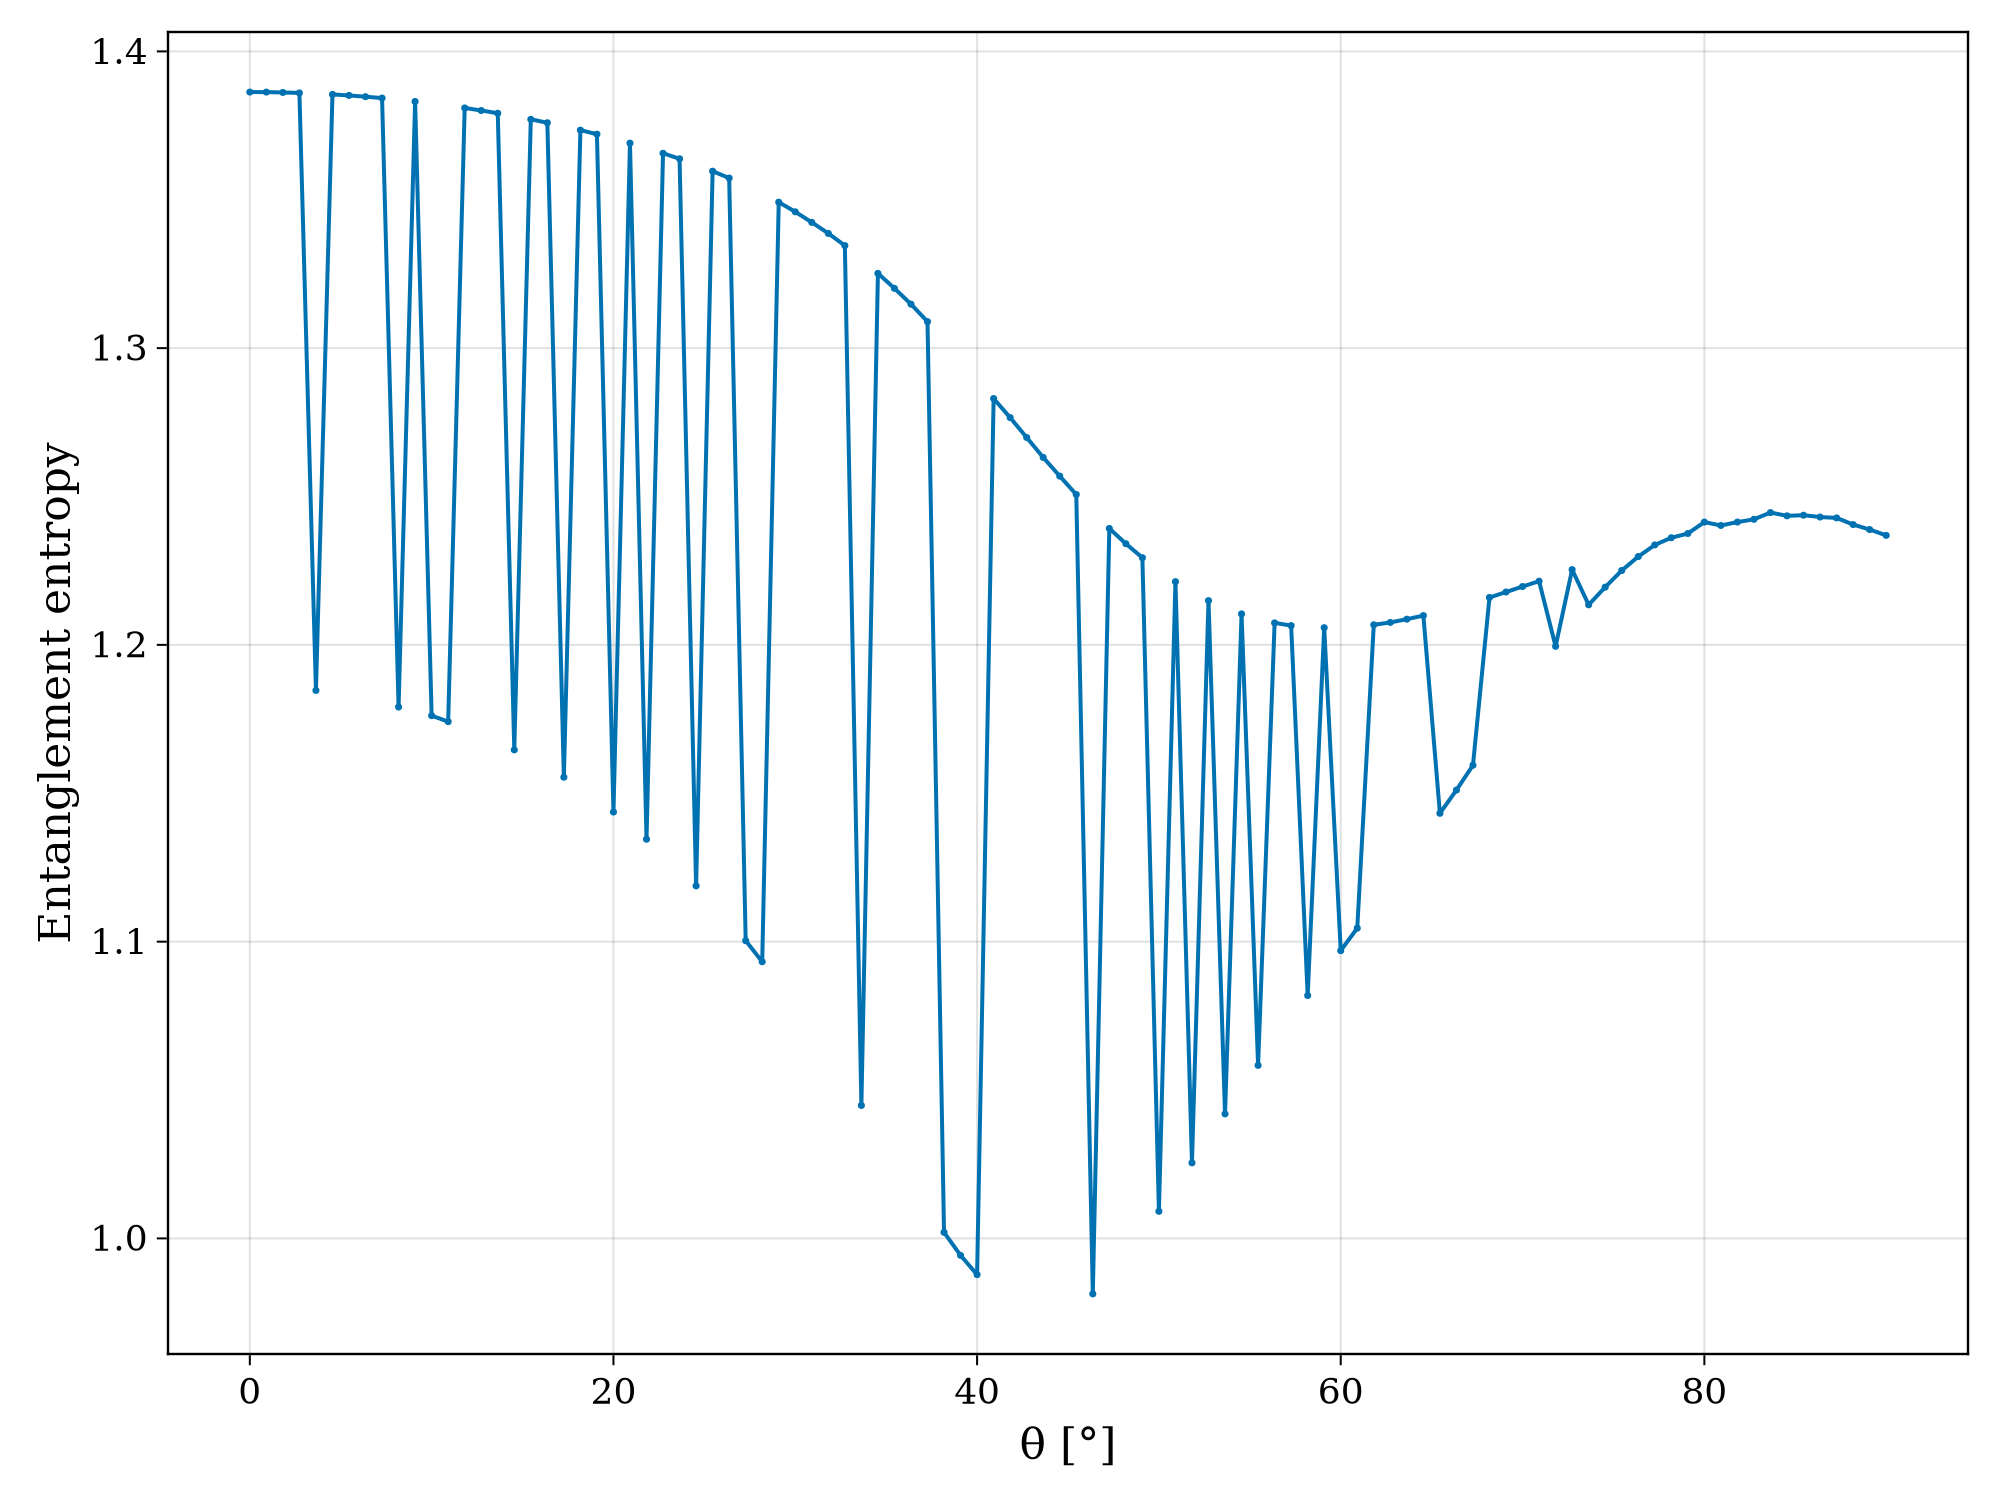

CairoMakie.Screen{IMAGE}


In [67]:
CGLMP_theta(4)

## Incompatibility vs $\theta$ (Second approximation)

The first measurement will be fixed in the computational basis $\{ |j\rangle \langle j | \}_j$, while the second measurement will be done in the basis $\{ \hat{F}_d^\theta |j\rangle \langle j| (\hat{F}_d^\dagger)^\theta \}$, where

\begin{equation*}
    \hat{F}_d = \frac{1}{\sqrt{d}} \sum_{j,k} \omega_d^{jk}|j\rangle \langle k | \quad \text{,} \quad \omega_d = e^{2\pi i/d}.
\end{equation*}


In [2]:
# Given an operator, return its projectors
function Projectors(A::AbstractMatrix)
    eigvec     = eigvecs(A)
    projectors = [eigvec[:, i] * eigvec[:, i]' for i in 1:size(eigvec, 2)] 
    return projectors
end

# Weyl operator in dimension d and subindexes m and n
function Weyl(d::Integer, m::Integer, n::Integer)
    U = zeros(ComplexF64, d, d)

    for i in 1:d
        col = mod(i-1 - n, d) + 1 
        U[i, col] = exp(2π * im * m * (i-1) / d)
    end

    return U
end

# Return the measurement {F^θ|i⟩}
function Fθ_measurement(d::Int, θ::Float64)
    Zd   = Weyl(d, 1, 0)
    comp = Projectors(Zd)

    F       = F_operator(d)

    E       = eigen(F)
    V       = E.vectors
    λ       = E.values
    Fθ      = V * Diagonal(λ .^ θ) * V'

    return [Fθ * P * Fθ' for P in comp]  
end 

Fθ_measurement (generic function with 1 method)

In [3]:
# Calculate the maximal violation of CGLMP in dimesion d for a meaurement fixed in Z and the other measurement tilted from θ∈[0,π/2]
function CGLMP_theta(d::Integer)
    N = 100
    θ = LinRange(0, 1, N)

    # Projectors of Z for qudits
    P_z = Projectors(Weyl(d, 1, 0))

    incomp = fill!(similar(θ), 0.0)
    cglmp  = fill!(similar(θ), 0.0)
    entang = fill!(similar(θ), 0.0)

    Threads.@threads for i in eachindex(θ)
        theta = θ[i]
        P_θ = Fθ_measurement(d, theta)

        incomp[i]   = MI_NC(P_z, P_θ, 2.0) 
        cglmp[i], ρ = CGLMP_opt([P_z, P_θ], [P_z, P_θ], d)
        entang[i]   = Ent_entropy(ρ, d, d)
    end

    return θ, incomp, cglmp, entang
end

function plot_CGLMP_theta(θ, incomp, cglmp, entang)
    set_theme!(Theme(
        fontsize = 18,
        fonts = (; regular = "CMU Serif"),
        Axis = (
            xgridvisible = true,
            ygridvisible = true,
            topspinevisible = true,
            rightspinevisible = true,
            spinewidth = 1.2,
        )
    ))

    f = Figure(size = (1000, 750))

    ax = Axis(f[1, 1],
        xlabel = "θ",
        ylabel = "Measurement Incompatibility",
        titlesize = 25,
        xlabelsize = 22,
        ylabelsize = 22
    )

    lines!(ax, θ, incomp, linewidth = 2)
    scatter!(ax, θ, incomp, markersize = 5)
    display(f)

    g = Figure(size = (1000, 750))

    ax = Axis(g[1, 1],
        xlabel = "θ",
        ylabel = "CGLMP maximal violation",
        titlesize = 25,
        xlabelsize = 22,
        ylabelsize = 22
    )

    lines!(ax, θ, cglmp, linewidth = 2)
    scatter!(ax, θ, cglmp, markersize = 5)
    display(g)

    h = Figure(size = (1000, 750))

    ax = Axis(h[1, 1],
        xlabel = "θ",
        ylabel = "Entanglement entropy",
        titlesize = 25,
        xlabelsize = 22,
        ylabelsize = 22
    )

    lines!(ax, θ, entang, linewidth = 2)
    scatter!(ax, θ, entang, markersize = 5)
    display(h)

end

plot_CGLMP_theta (generic function with 1 method)

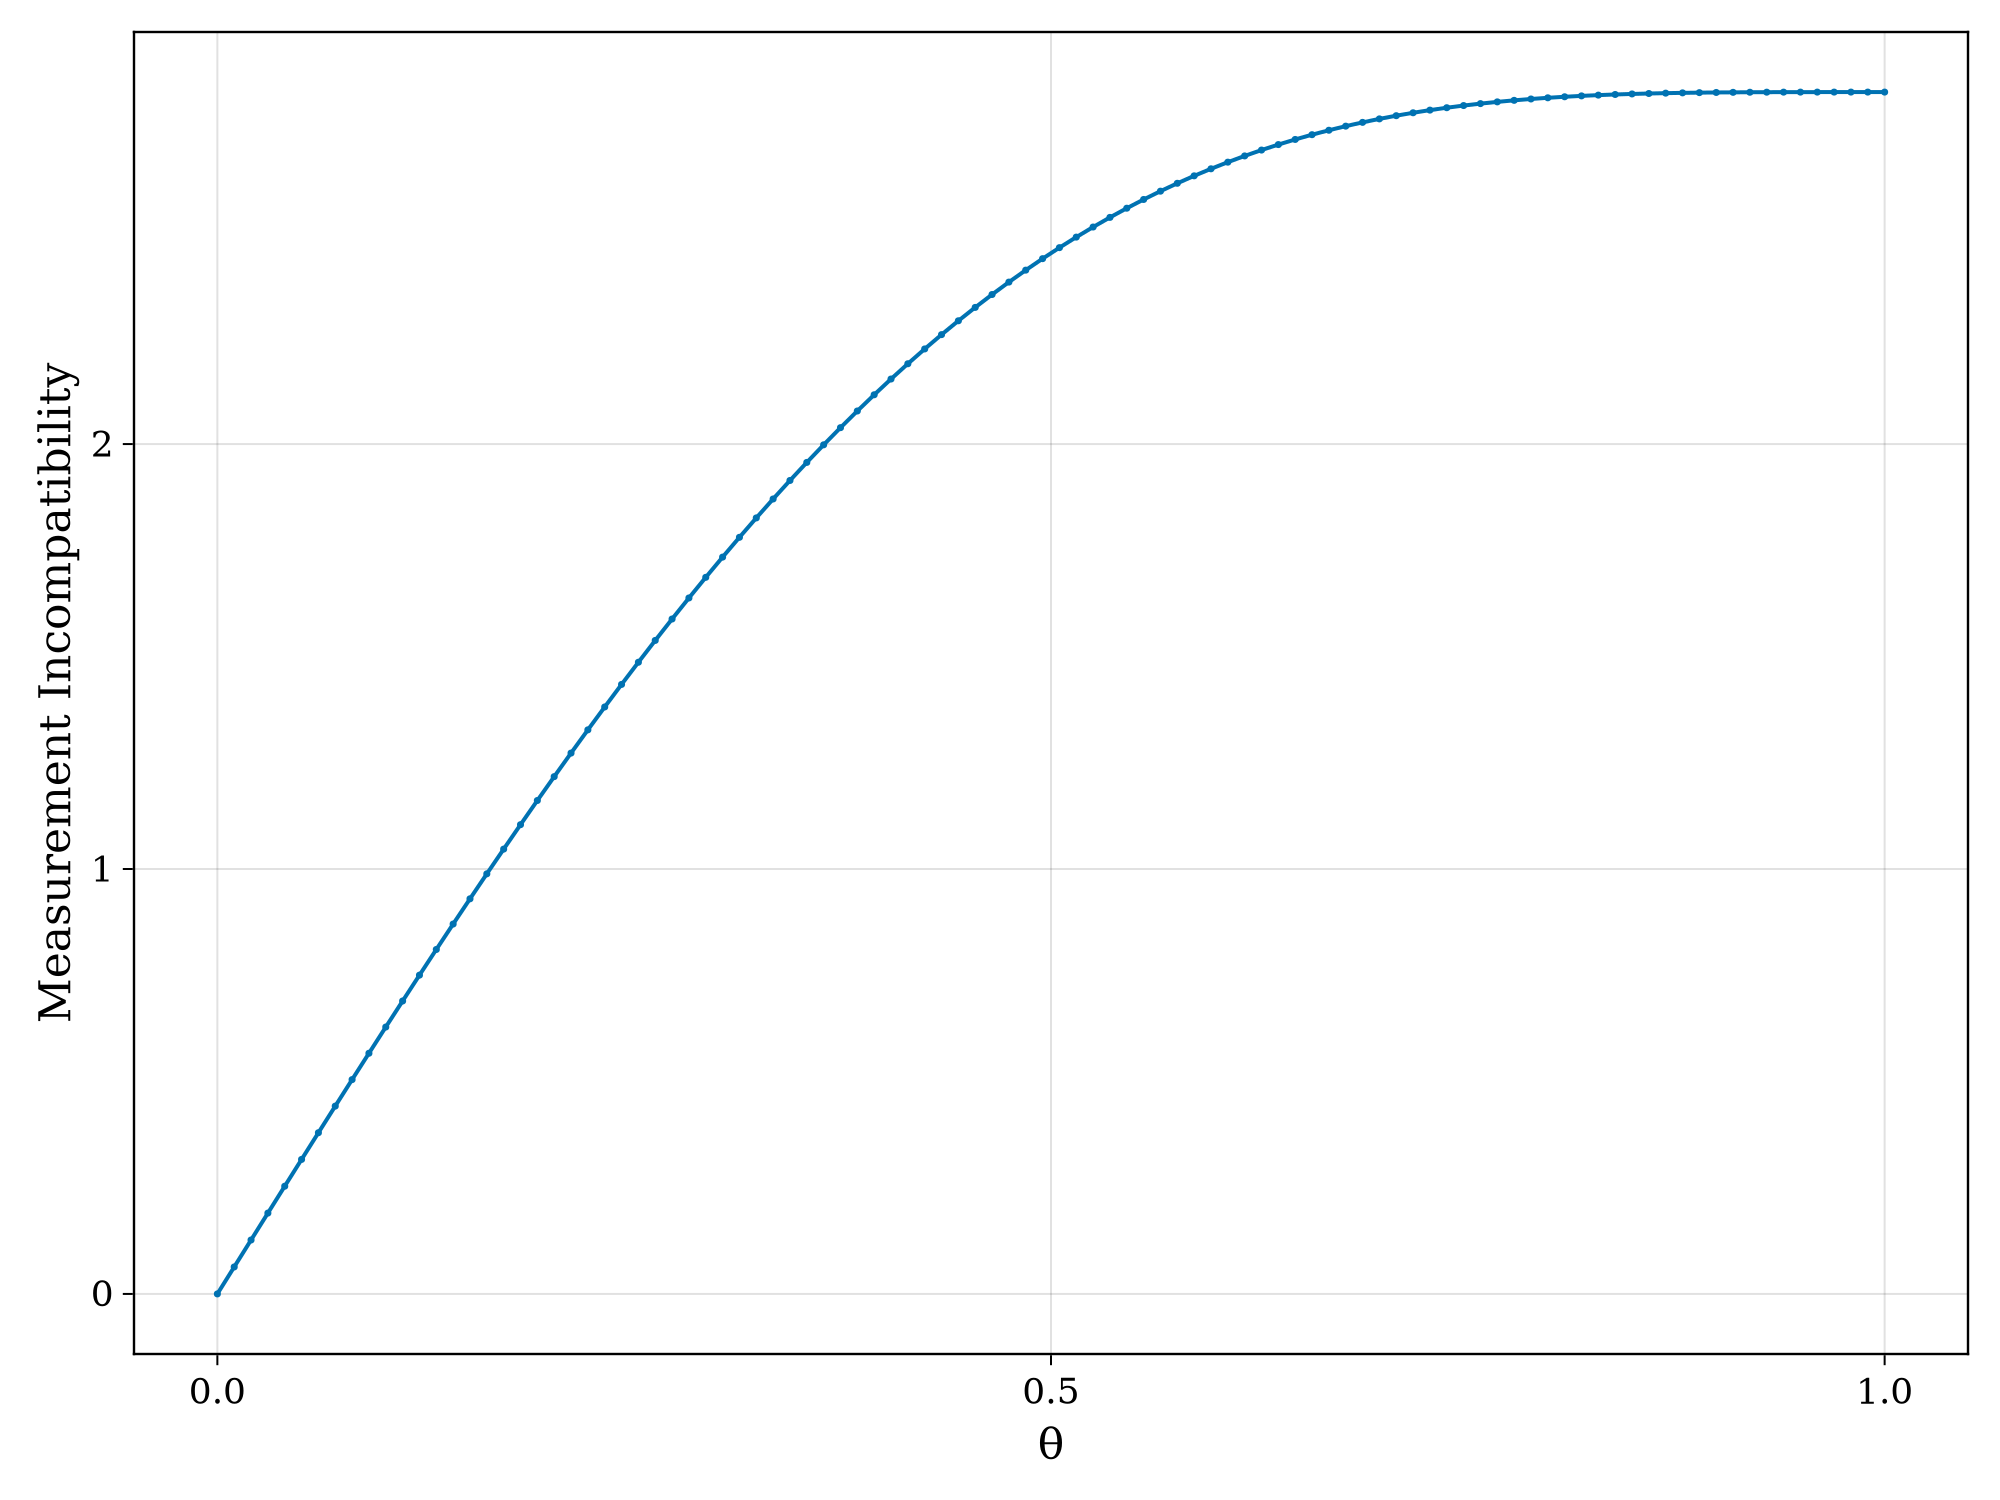

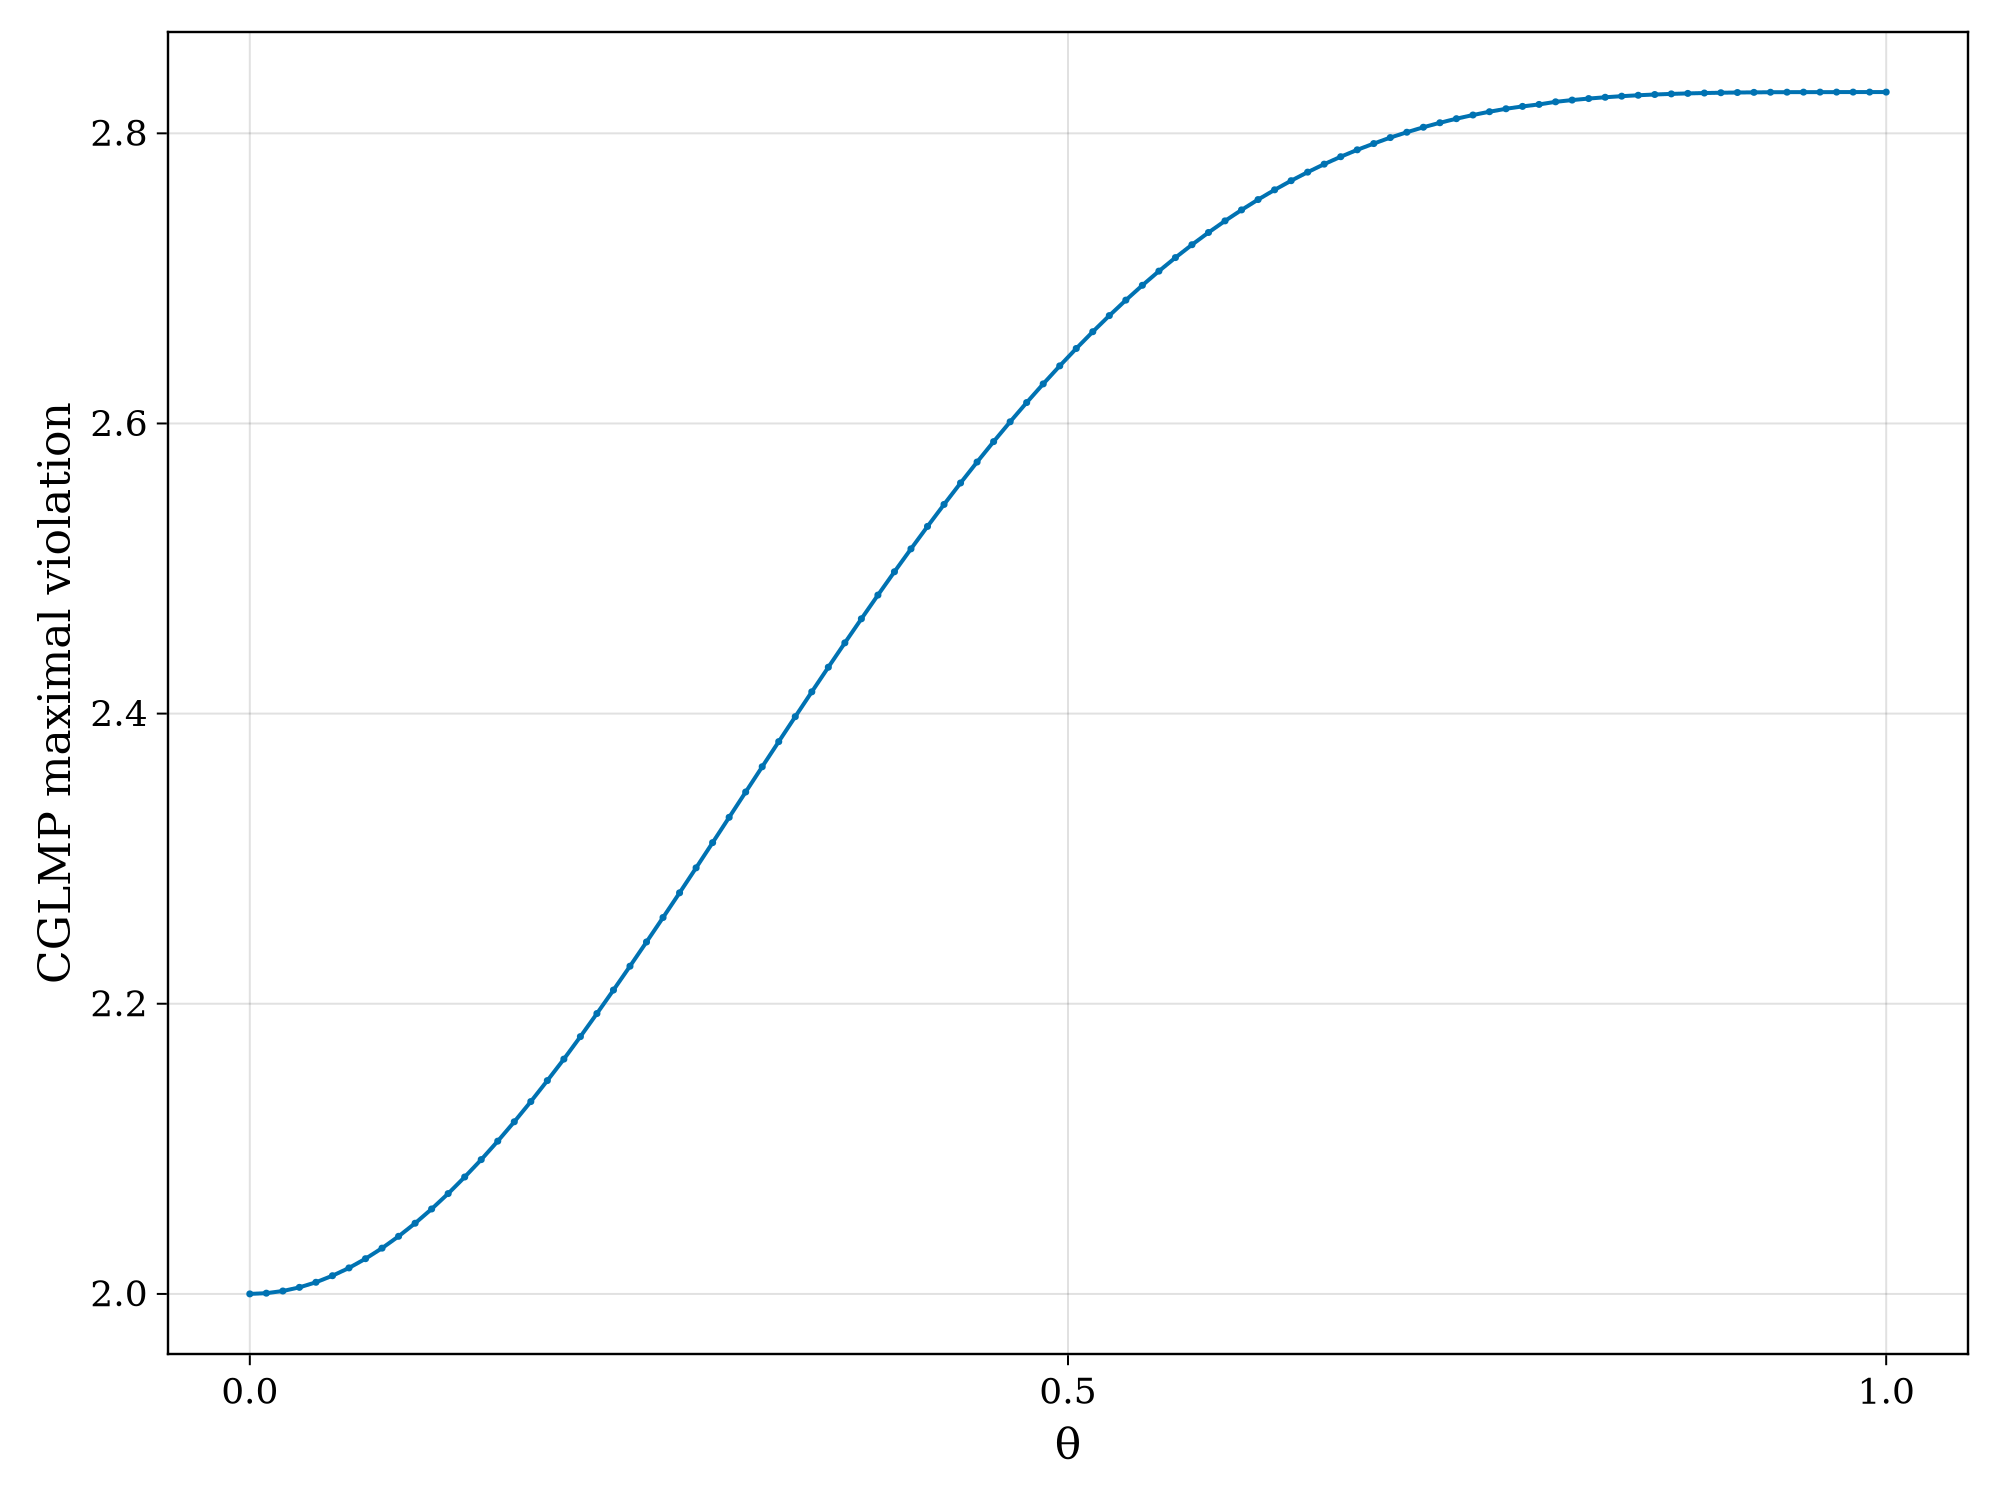

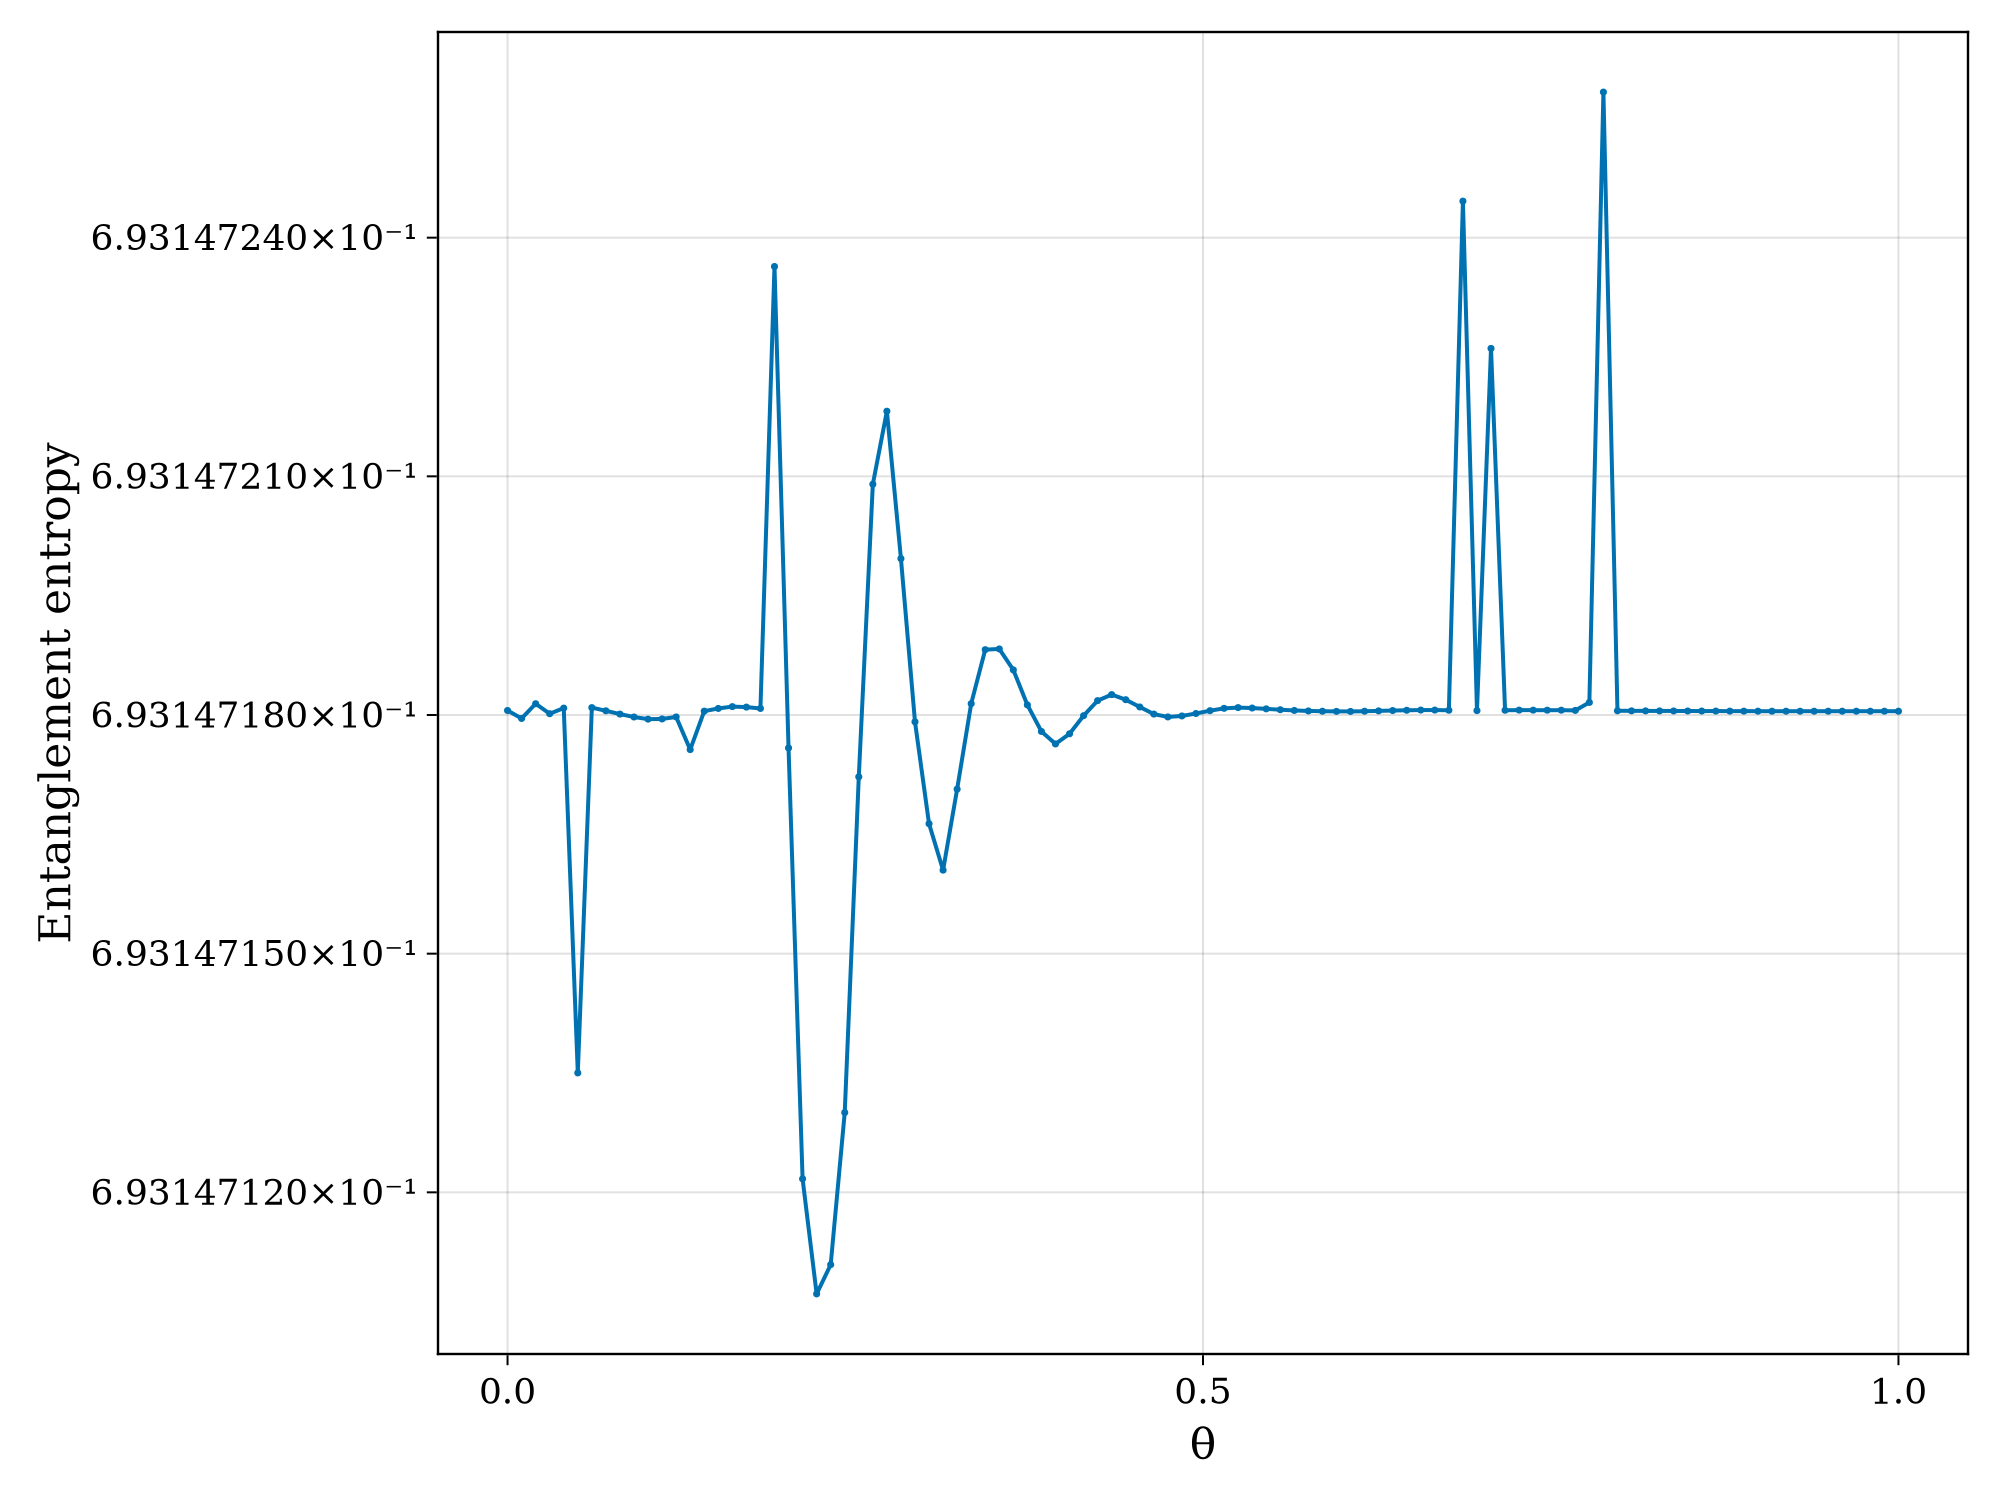

CairoMakie.Screen{IMAGE}


In [8]:
thetas, incomp, cglmp, entang = CGLMP_theta(2)
plot_CGLMP_theta(thetas, incomp, cglmp, entang)